# Predictive Modeling & Failure Analysis

## Goal
Build a model to predict `deal_stage` (Won/Lost) and perform a **rigorous failure analysis** to understand where the model (and potentially the sales process) falls short.

## Approach
1. **Feature Engineering**: Create features that capture the "quality" of the opportunity.
2. **Modeling**: Use Gradient Boosting for high performance.
3. **Failure Analysis**: Isolate incorrect predictions and find patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load Data
try:
    df = pd.read_csv("../data/processed/processed_sales_data.csv")
except FileNotFoundError:
    df = pd.read_csv("data/processed/processed_sales_data.csv")

print(f"Loaded data shape: {df.shape}")

Loaded data shape: (6711, 27)


## 1. Feature Engineering & Selection
We must exclude features that are treated as "outcomes" (like `close_date`, `close_value`, `deal_duration`) to avoid **data leakage**.

In [2]:
# Define Features
# Exclude: 'deal_duration_days', 'close_value', 'log_close_value', 'close_year', 'close_month'
# Include: 'sector', 'year_established', 'revenue', 'employees', 'office_location', 
#          'series', 'sales_price', 'product', 'manager', 'regional_office', 
#          'engage_year', 'engage_month', 'log_revenue', 'log_employees'

features = [
    'sector', 'year_established', 'revenue', 'employees', 'office_location', 
    'series', 'sales_price', 'product', 'manager', 'regional_office', 
    'engage_year', 'engage_month', 'log_revenue', 'log_employees'
]

target = 'target'

# Check for missing values in features
print("Missing values in features:")
print(df[features].isnull().sum())

# Drop missing or fill (already handled in prep, but good to be safe)
df = df.dropna(subset=features)

X = df[features]
y = df[target]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Testing shapes: {X_test.shape}, {y_test.shape}")

Missing values in features:
sector              0
year_established    0
revenue             0
employees           0
office_location     0
series              0
sales_price         0
product             0
manager             0
regional_office     0
engage_year         0
engage_month        0
log_revenue         0
log_employees       0
dtype: int64
Training shapes: (5368, 14), (5368,)
Testing shapes: (1343, 14), (1343,)


## 2. Model Training (Gradient Boosting)
We use a Pipeline to handle preprocessing (OneHotEncoding for categoricals) and Modeling.

In [3]:
# specific categorical columns
categorical_features = ['sector', 'office_location', 'series', 'product', 'manager', 'regional_office']
numeric_features = ['year_established', 'revenue', 'employees', 'sales_price', 'engage_year', 'engage_month', 'log_revenue', 'log_employees']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Gradient Boosting Classifier
clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))])

clf.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 3. Evaluation
Check accuracy, precision, recall, and ROC-AUC.

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.01      0.01       495
           1       0.63      0.99      0.77       848

    accuracy                           0.63      1343
   macro avg       0.43      0.50      0.39      1343
weighted avg       0.48      0.63      0.49      1343

ROC-AUC Score: 0.5352


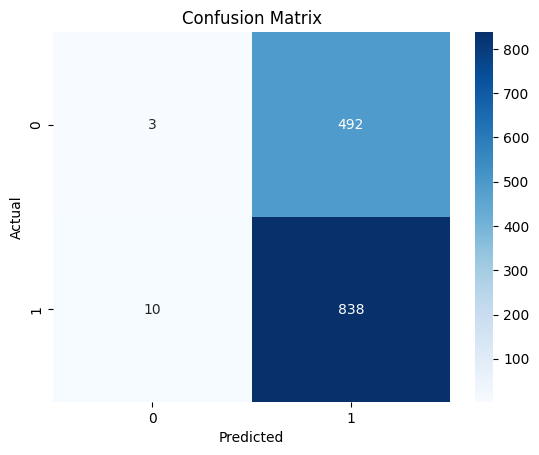

In [4]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 4. Failure Analysis
This is the critical step. We analyze **where** the model failed.
We will isolate the False Positives (Predicted Won, Actual Lost) and False Negatives (Predicted Lost, Actual Won).

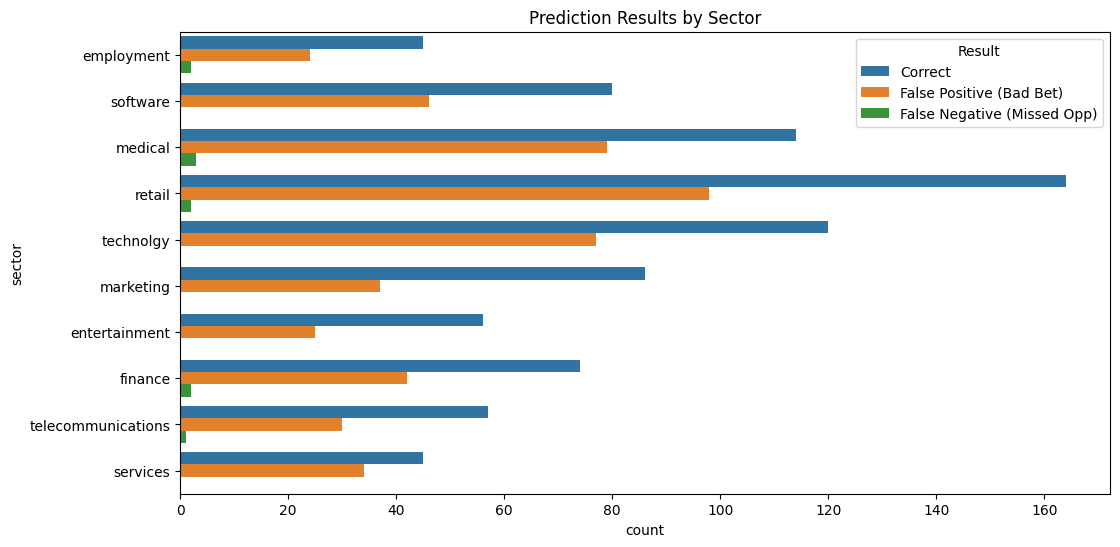

High Confidence False Positives (Model was >80% sure but lost): 11
         sector         product  sales_price  Probability
389   technolgy  GTX Plus Basic       1096.0     0.879851
225    services      MG Special         55.0     0.846602
109   marketing  GTX Plus Basic       1096.0     0.876303
4183  technolgy          GTXPro       1096.0     0.810165
223   technolgy          GTXPro       1096.0     0.861290
High Confidence False Negatives (Model was <20% sure but won): 0


In [5]:
# Create a Failure DataFrame
failure_df = X_test.copy()
failure_df['Actual'] = y_test
failure_df['Predicted'] = y_pred
failure_df['Probability'] = y_prob

# Define Errors
failure_df['Result'] = 'Correct'
failure_df.loc[(failure_df['Actual']==1) & (failure_df['Predicted']==0), 'Result'] = 'False Negative (Missed Opp)'
failure_df.loc[(failure_df['Actual']==0) & (failure_df['Predicted']==1), 'Result'] = 'False Positive (Bad Bet)'

# Visualize Error Distribution by Sector
plt.figure(figsize=(12, 6))
sns.countplot(data=failure_df, y='sector', hue='Result')
plt.title("Prediction Results by Sector")
plt.show()

# High Confidence Failures
high_conf_fp = failure_df[(failure_df['Result'] == 'False Positive (Bad Bet)') & (failure_df['Probability'] > 0.8)]
print(f"High Confidence False Positives (Model was >80% sure but lost): {len(high_conf_fp)}")
if len(high_conf_fp) > 0:
    print(high_conf_fp[['sector', 'product', 'sales_price', 'Probability']].head())

high_conf_fn = failure_df[(failure_df['Result'] == 'False Negative (Missed Opp)') & (failure_df['Probability'] < 0.2)]
print(f"High Confidence False Negatives (Model was <20% sure but won): {len(high_conf_fn)}")
if len(high_conf_fn) > 0:
    print(high_conf_fn[['sector', 'product', 'sales_price', 'Probability']].head())


## 5. What Drives Predictions? (Feature Importance)

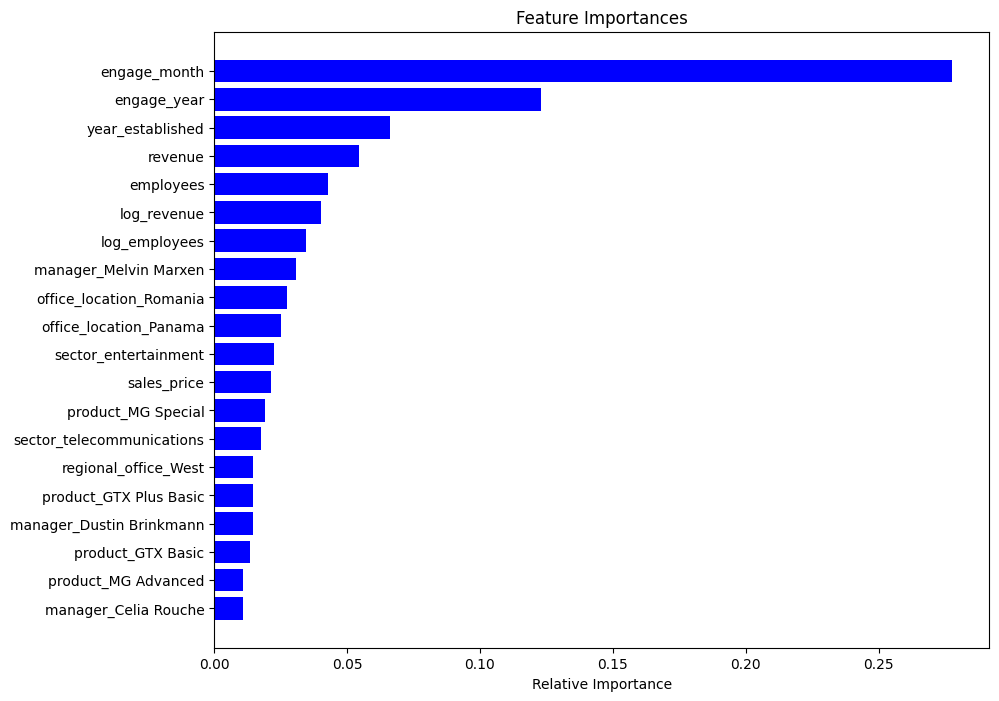

In [6]:
# feature importance
# Accessing feature names is tricky with Pipeline + OneHotEncoder
# We make a best effort to map them

ohe = clf.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_feature_names)

importances = clf.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[-20:] # Top 20

plt.figure(figsize=(10, 8))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## 6. Logistic Regression Baseline
Train a baseline Logistic Regression model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

# Logistic Regression with balanced class weights
lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

## 7. Random Forest Classifier
Train a Random Forest model for comparison.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST RESULTS")
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

## 8. Text-Based Model with Generated Conversations
Create synthetic conversation text and train a text-based model.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Generate conversation text from features
def generate_conversation(row):
    duration = row['deal_duration_days'] if 'deal_duration_days' in row else 60
    sector = row['sector']
    product = row['product']
    revenue = row['revenue']
    
    # Revenue category
    if revenue > 4000:
        revenue_desc = "enterprise-level organization"
        focus_area = "long-term scalability and compliance requirements"
    elif revenue > 1500:
        revenue_desc = "mid-market company"
        focus_area = "cost optimization and integration planning"
    else:
        revenue_desc = "growing business"
        focus_area = "initial adoption and pricing flexibility"
    
    # Duration category
    if duration > 120:
        engagement_desc = "multiple strategic discussions"
    elif duration > 60:
        engagement_desc = "several follow-up meetings"
    else:
        engagement_desc = "brief evaluation calls"
    
    return (
        f"A {revenue_desc} in the {sector} sector had {engagement_desc} "
        f"regarding the {product}. Discussions focused on {focus_area}, "
        f"implementation timelines, and expected operational impact."
    )

# Create conversation text
df_with_text = df.copy()
df_with_text['conversation_text'] = df_with_text.apply(generate_conversation, axis=1)

print(df_with_text[['conversation_text', 'target']].head())

In [ ]:
# Train text-only model
X_text = df_with_text['conversation_text']
y_text = df_with_text['target']

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y_text,
    test_size=0.2,
    random_state=42,
    stratify=y_text
)

text_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

text_model.fit(X_train_text, y_train_text)

y_pred_text = text_model.predict(X_test_text)
y_prob_text = text_model.predict_proba(X_test_text)[:, 1]

print("TEXT MODEL RESULTS")
print("F1 Score:", f1_score(y_test_text, y_pred_text))
print("ROC-AUC:", roc_auc_score(y_test_text, y_prob_text))
print(classification_report(y_test_text, y_pred_text))

## 9. XGBoost Classifier
Train an XGBoost model for enhanced performance.

In [ ]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBOOST RESULTS")
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

## 10. XGBoost Hyperparameter Tuning
Use GridSearchCV to find optimal hyperparameters.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__n_estimators': [200, 300, 400]
}

grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)